# Notebook 1: Modell-Inspektion
**Kurs:** Mechanistic Interpretability  
**Modell:** EleutherAI/pythia-410m  
**Ziel:** Pythia-410M laden, Architektur verstehen und erste Vorhersagen generieren.

> **Aufgabe:** Implementiere die Zellen schrittweise. Hilfreiche Dokumentation:
> - HuggingFace Transformers: https://huggingface.co/docs/transformers/
> - Pythia-Modell: https://huggingface.co/EleutherAI/pythia-410m
> - PyTorch: https://pytorch.org/docs/stable/

## 1. Installation & Imports

In [18]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import os
import numpy as np
from sklearn.decomposition import PCA
import pandas as pd
from sklearn.manifold import TSNE
# TODO: Installiere benötigte Pakete (auskommentieren und einmalig ausführen)
# \!pip install transformers torch accelerate

# TODO: Importiere die folgenden Bibliotheken:
#   - torch
#   - numpy as np
#   - matplotlib.pyplot as plt
#   - AutoModelForCausalLM, AutoTokenizer aus transformers

# Hinweis: torch.cuda.is_available() prüft, ob eine GPU vorhanden ist
# Hinweis: Dokumentation zu AutoModelForCausalLM:
#   https://huggingface.co/docs/transformers/model_doc/auto#transformers.AutoModelForCausalLM

## 2. Modell und Tokenizer laden

In [19]:
MODEL_NAME = "EleutherAI/pythia-410m"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Tokenizer laden
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Modell laden
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    attn_implementation="eager",   # wichtig für Attention-Ausgabe
    torch_dtype=torch.float32
)

# Auf Gerät verschieben
model = model.to(device)

# Eval-Modus
model.eval()

print("Modell geladen!")
print("Device:", device)
# Fallback, falls Pythia nicht lädt: MODEL_NAME = "gpt2-medium"

# TODO: Lade Tokenizer und Modell von HuggingFace
#   - AutoTokenizer.from_pretrained(MODEL_NAME)
#   - AutoModelForCausalLM.from_pretrained(MODEL_NAME)
#   - Verschiebe das Modell auf das richtige Gerät (.to(device))
#   - Setze das Modell in den Evaluierungs-Modus (.eval())
#   - Setze das Attn-Implementation auf "eager". Achtung, wenn dies nicht geladen wird, dann werden Attentions-Schichten nicht korrekt zurückgegeben.
# model = # AutoModelForCausalLM.from_pretrained(                                                                                       #     
#      MODEL_NAME, 
#      attn_implementation="eager",   # <-- entscheidend
#      #torch_dtype=torch.float32,                                                                                                          
#  ).to(device)
#  model.eval()  


# Hinweis: Falls der Tokenizer keinen pad_token hat, setze:
#   tokenizer.pad_token = tokenizer.eos_token
#
# Dokumentation: https://huggingface.co/docs/transformers/main_classes/tokenizer

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

Modell geladen!
Device: cuda


In [20]:


texts = [
    "tina is a girl.she has cat",
    "Berlin is the capital of",
    "AI",                    
]
tokens = tokenizer(texts,  padding=True )

print(tokens)

{'input_ids': [[85, 1758, 310, 247, 3226, 15, 6689, 556, 5798], [23666, 3642, 310, 253, 5347, 273, 1, 1, 1], [18128, 1, 1, 1, 1, 1, 1, 1, 1]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 0, 0, 0], [1, 0, 0, 0, 0, 0, 0, 0, 0]]}


## 3. Architekturübersicht

In [21]:
# TODO: Gib die wichtigsten Architektur-Parameter aus:
#   - model.config.model_type
#   - model.config.hidden_size
#   - model.config.num_hidden_layers
#   - model.config.num_attention_heads
#   - model.config.vocab_size
#   - model.config.max_position_embeddings
#
# Hinweis: head_dimension = hidden_size / num_attention_heads
# Hinweis: Alle Konfigurationsparameter: https://huggingface.co/docs/transformers/model_doc/gpt_neox#transformers.GPTNeoXConfig


print("Model type:", model.config.model_type)
print("Hidden size:", model.config.hidden_size)
print("Hidden layers:", model.config.num_hidden_layers)
print("Attention heads:", model.config.num_attention_heads)
print("Vocabulary size:", model.config.vocab_size)
print("Max position embeddings:", model.config.max_position_embeddings)

# محاسبه ابعاد هر Head
head_dimension = (
    model.config.hidden_size /
    model.config.num_attention_heads
)

print("Head dimension:", head_dimension)

Model type: gpt_neox
Hidden size: 1024
Hidden layers: 24
Attention heads: 16
Vocabulary size: 50304
Max position embeddings: 2048
Head dimension: 64.0


In [22]:
model

GPTNeoXForCausalLM(
  (gpt_neox): GPTNeoXModel(
    (embed_in): Embedding(50304, 1024)
    (emb_dropout): Dropout(p=0.0, inplace=False)
    (layers): ModuleList(
      (0-23): 24 x GPTNeoXLayer(
        (input_layernorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (post_attention_layernorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (post_attention_dropout): Dropout(p=0.0, inplace=False)
        (post_mlp_dropout): Dropout(p=0.0, inplace=False)
        (attention): GPTNeoXAttention(
          (query_key_value): Linear(in_features=1024, out_features=3072, bias=True)
          (dense): Linear(in_features=1024, out_features=1024, bias=True)
        )
        (mlp): GPTNeoXMLP(
          (dense_h_to_4h): Linear(in_features=1024, out_features=4096, bias=True)
          (dense_4h_to_h): Linear(in_features=4096, out_features=1024, bias=True)
          (act): GELUActivation()
        )
      )
    )
    (final_layer_norm): LayerNorm((1024,), eps=1e-05, 

## 4. Parameter-Zählung

In [23]:
# TODO: Schreibe eine Funktion count_params(module) die die Gesamtzahl
#   der Parameter in einem Modul zählt.
#   Tipp: module.parameters() liefert alle Parameter-Tensoren.
#   Tipp: p.numel() gibt die Anzahl der Elemente eines Tensors zurück.
#
# TODO: Berechne die Parameterzahl für:
#   - Token-Embedding: model.gpt_neox.embed_in
#   - Jede Transformer-Schicht: model.gpt_neox.layers[i]
#   - Final LayerNorm: model.gpt_neox.final_layer_norm
#   - Unembed (LM-Head): model.embed_out
#
# Tipp: Prozentualer Anteil = component_params / total_params * 100

def count_params(module):
    return sum(p.numel() for p in module.parameters())

total_params = count_params(model)

print(f"Total params: {total_params:,}\n")

# Token Embedding
embed_params = count_params(model.gpt_neox.embed_in)

print(
    f"Embedding: {embed_params:,} "
    f"({embed_params/total_params*100:.2f}%)"
)

    

Total params: 405,334,016

Embedding: 51,511,296 (12.71%)


Total params: 405,334,016

Token Embedding          :      51,511,296  (12.708%)
All Transformer Layers   :     302,309,376  (74.583%)
Final LayerNorm          :           2,048  ( 0.001%)
Output / Unembedding     :      51,511,296  (12.708%)


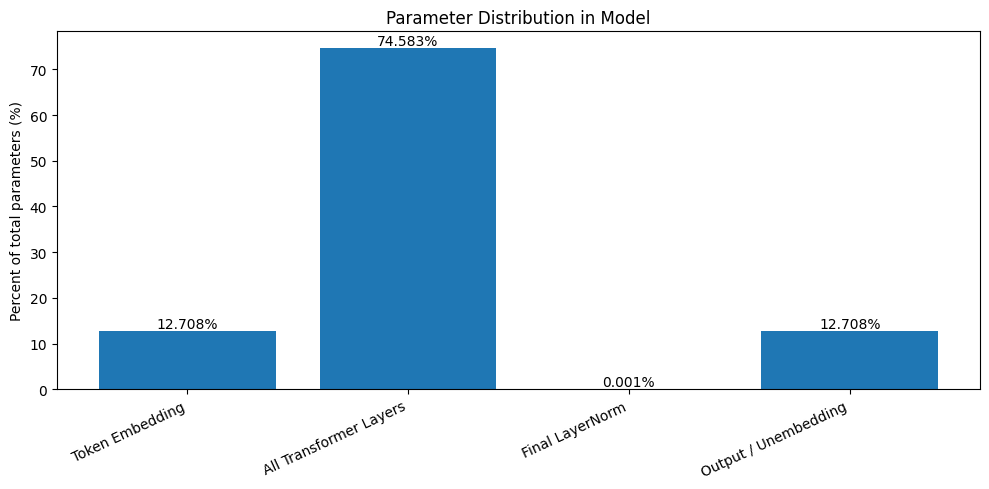

In [24]:

parts = {}

# 1) Token Embedding
parts["Token Embedding"] = count_params(model.gpt_neox.embed_in)

# 2) همه Transformer Layers
parts["All Transformer Layers"] = count_params(model.gpt_neox.layers)

# 3) Final LayerNorm
parts["Final LayerNorm"] = count_params(model.gpt_neox.final_layer_norm)

# 4) Output / Unembedding
# ا embed_out 

parts["Output / Unembedding"] = count_params(model.embed_out)

print("Total params:", f"{total_params:,}")
print()

for name, value in parts.items():
    percent = value / total_params * 100
    print(f"{name:25s}: {value:15,}  ({percent:6.3f}%)")

names = list(parts.keys())
values = list(parts.values())
percents = [v / total_params * 100 for v in values]

plt.figure(figsize=(10, 5))
bars = plt.bar(names, percents)

plt.ylabel("Percent of total parameters (%)")
plt.title("Parameter Distribution in Model")
plt.xticks(rotation=25, ha="right")

for bar, percent in zip(bars, percents):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{percent:.3f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

Detailed parameter breakdown:

Token Embedding          :      51,511,296  (12.708%)
Attention                :     100,761,600  (24.859%)
MLP                      :     201,449,472  (49.700%)
LayerNorms in Layers     :          98,304  ( 0.024%)
Final LayerNorm          :           2,048  ( 0.001%)
Output / Unembedding     :      51,511,296  (12.708%)


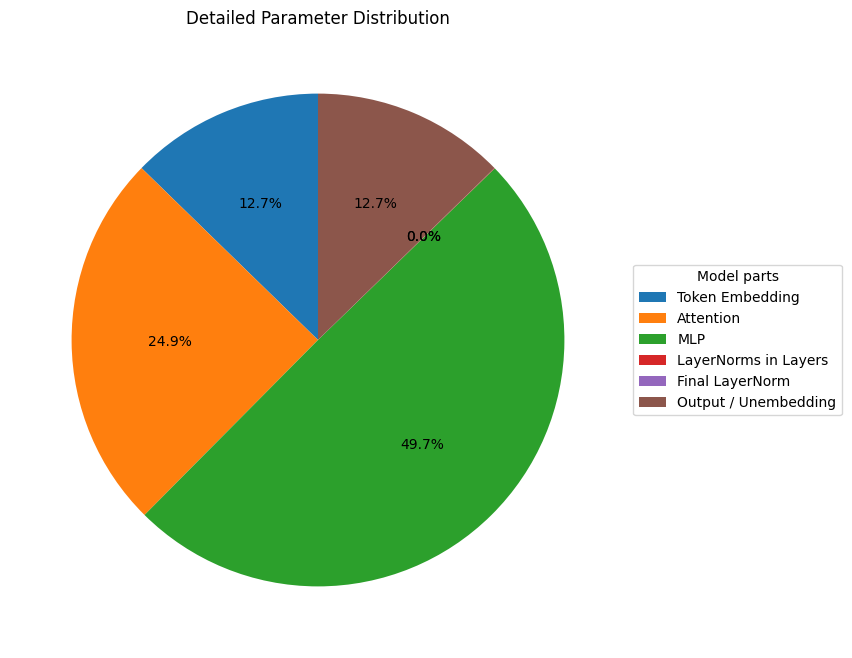

In [25]:
parts_detail = {}

# Embedding
parts_detail["Token Embedding"] = count_params(model.gpt_neox.embed_in)

# Attention
parts_detail["Attention"] = sum(
    count_params(layer.attention)
    for layer in model.gpt_neox.layers
)

# MLP 
parts_detail["MLP"] = sum(
    count_params(layer.mlp)
    for layer in model.gpt_neox.layers
)

# LayerNorm   
parts_detail["LayerNorms in Layers"] = sum(
    count_params(layer.input_layernorm) +
    count_params(layer.post_attention_layernorm)
    for layer in model.gpt_neox.layers
)

# Final LayerNorm
parts_detail["Final LayerNorm"] = count_params(model.gpt_neox.final_layer_norm)

# Output
parts_detail["Output / Unembedding"] = count_params(model.embed_out)

print("Detailed parameter breakdown:")
print("")

for name, value in parts_detail.items():
    percent = value / total_params * 100
    print(f"{name:25s}: {value:15,}  ({percent:6.3f}%)")

# Pie chart
plt.figure(figsize=(8, 8))
wedges, texts, autotexts =plt.pie(
    parts_detail.values(),
    labels=None,    
    autopct="%1.1f%%",
    startangle=90
)
plt.legend(
    wedges,
    parts_detail.keys(),
    title="Model parts",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)
plt.title("Detailed Parameter Distribution")
plt.show()

min = -0.406005859375
max = 0.38916015625
mean = -8.438722943537869e-06
std = 0.024761170148849487


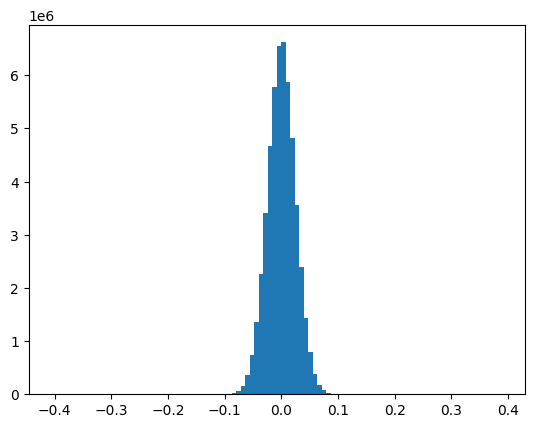

In [26]:
embn = model.gpt_neox.embed_in.weight.detach().cpu().flatten()
print("min =", embn.min().item())
print("max =", embn.max().item())
print("mean =", embn.mean().item())
print("std =", embn.std().item())

plt.hist(embn.numpy(), bins=100)
plt.show()

In [27]:
emb = model.gpt_neox.embed_in.weight.detach().cpu()

words = [
    " good",
    " great",
    " excellent",
    " bad",
    " terrible",
]

# token id


for word in words:

    token_id = tokenizer(word, add_special_tokens=False)["input_ids"][0]

    vec = emb[token_id]

    values, dims = vec.topk(10)

    print(f"\n{word}")

    for d in dims:
        print(d.item(), end=" ")
    


 good
621 777 980 636 32 851 877 191 500 694 
 great
406 605 389 577 488 32 725 980 519 493 
 excellent
48 500 599 552 713 488 106 64 860 616 
 bad
435 318 857 691 469 80 698 432 352 819 
 terrible
822 909 242 313 488 203 857 429 185 753 

In [28]:
good_id = tokenizer(" good", add_special_tokens=False)["input_ids"][0]
good_vec = emb[good_id]

sim = F.cosine_similarity(
    good_vec.unsqueeze(0),
    emb,
    dim=1
)

values, ids = sim.topk(20)



labels = []

for v, idx in zip(values, ids):
    label = tokenizer.decode([idx.item()])
    labels.append(label)
    print(f"{v.item():.3f}", repr(label))



1.000 ' good'
0.733 'good'
0.671 ' Good'
0.645 'Good'
0.551 ' GOOD'
0.443 ' excellent'
0.389 ' bad'
0.370 ' better'
0.362 ' great'
0.351 ' decent'
0.345 'cellent'
0.318 ' Excellent'
0.315 ' nice'
0.299 ' best'
0.283 'Excellent'
0.281 ' poor'
0.276 'better'
0.268 'bad'
0.257 ' Bad'
0.257 'Nice'


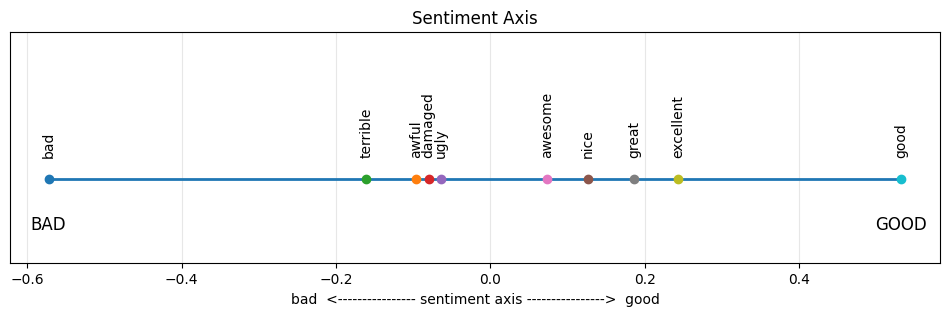

In [68]:
good_id = tokenizer(" good", add_special_tokens=False)["input_ids"][0]
bad_id  = tokenizer(" bad",  add_special_tokens=False)["input_ids"][0]

good_vec = emb[good_id]
bad_vec  = emb[bad_id]

words = [
    " bad",
    " awful",
    " terrible",
    " damaged",
    " ugly",
    " nice",
    " awesome",
    " great",
    " excellent",
    " good",
]

direction = good_vec - bad_vec

scores = []

for w in words:
    idx = tokenizer(w, add_special_tokens=False)["input_ids"][0]
    score = F.cosine_similarity(
        emb[idx].unsqueeze(0),
        direction.unsqueeze(0)
    ).item()
    scores.append(score)

bad_score = scores[words.index(" bad")]
good_score = scores[words.index(" good")]

plt.figure(figsize=(12, 3))

plt.hlines(0, bad_score, good_score, linewidth=2)

for w, s in zip(words, scores):
    plt.plot(s, 0, "o")
    plt.text(
        s, 
        0.05, 
        w.strip(), 
        rotation=90, 
        ha="center", 
        va="bottom"
    )

plt.text(bad_score, -0.12, "BAD", ha="center", fontsize=12)
plt.text(good_score, -0.12, "GOOD", ha="center", fontsize=12)

plt.xlim(bad_score - 0.05, good_score + 0.05)
plt.ylim(-0.2, 0.35)
plt.yticks([])

plt.xlabel("bad  <---------------- sentiment axis ---------------->  good")
plt.title("Sentiment Axis")
plt.grid(axis="x", alpha=0.3)

plt.show()

In [37]:

df = pd.read_csv("../data/annotations.csv")
df.head()


,Positive,Negative
0,good,bad
1,great,terrible
2,excellent,awful
3,amazing,horrible
4,wonderful,disgusting


C:\Users\alire\AppData\Local\Temp\ipykernel_35284\1444416661.py:20: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:257.)
  X = torch.tensor(word_vectors).numpy()


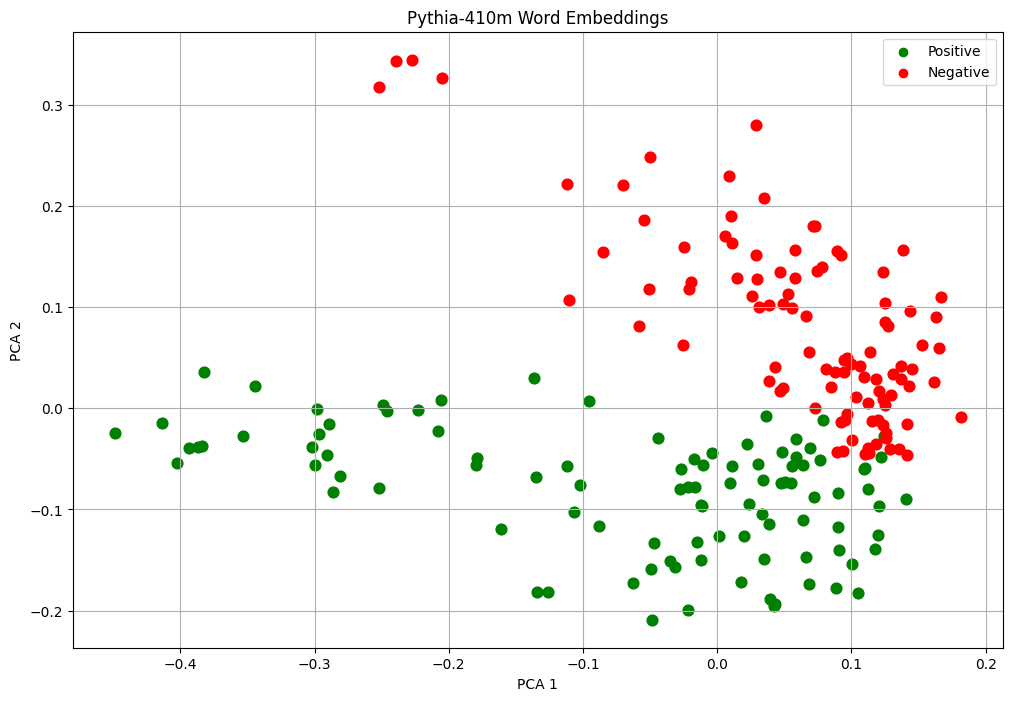

In [38]:


positive_words = df["Positive"].dropna().astype(str).tolist()
negative_words = df["Negative"].dropna().astype(str).tolist()

words = positive_words + negative_words
labels = ["Positive"] * len(positive_words) + ["Negative"] * len(negative_words)
emb = model.gpt_neox.embed_in.weight.detach().cpu()

# 4) Get word embedding
word_vectors = []

for word in words:
    token_ids = tokenizer(" " + word, add_special_tokens=False)["input_ids"]
    
    # اگر کلمه چند token شد، میانگین embeddingها را می‌گیریم
    token_vecs = emb[token_ids]
    word_vec = token_vecs.mean(dim=0)
    
    word_vectors.append(word_vec.numpy())

X = torch.tensor(word_vectors).numpy()

# 5) PCA to 2D
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

# 6) Plot
plt.figure(figsize=(12, 8))

for word, label, point in zip(words, labels, X_2d):
    x, y = point

    if label == "Positive":
        plt.scatter(x, y, color="green", s=60)
    else:
        plt.scatter(x, y, color="red", s=60)


# Legend
plt.scatter([], [], color="green", label="Positive")
plt.scatter([], [], color="red", label="Negative")
plt.legend()
plt.title("Pythia-410m Word Embeddings")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True)
plt.show()

## 5. Top-K Vorhersagen

In [31]:
# TODO: Schreibe eine Funktion top_k_predictions(prompt, k=5) die:
#   1. Den Prompt tokenisiert (tokenizer(prompt, return_tensors="pt"))
#   2. Einen Forward Pass durchführt (model(**inputs))
#   3. Die Logits des LETZTEN Tokens nimmt (outputs.logits[0, -1, :])
#   4. Softmax anwendet und die Top-K Tokens zurückgibt
#
# Hinweis: torch.topk(probs, k) gibt Werte und Indizes zurück
# Hinweis: tokenizer.decode([token_id]) konvertiert einen Token-Index in Text
#
# Dokumentation zu torch.topk:
#   https://pytorch.org/docs/stable/generated/torch.topk.html
#
# Teste deine Funktion mit den Prompts:
#   "The capital of France is"
#   "The Eiffel Tower is located in"
#   "Python is a programming"
def top_k_predictions(prompt, k=5):

    # 1) Prompt tokenisieren
    inputs = tokenizer(
        prompt,
        return_tensors="pt"
    )

    # auf CPU/GPU verschieben
    inputs = {key: value.to(device)
              for key, value in inputs.items()}

    # Kein Gradient nötig
    with torch.no_grad():
        outputs = model(**inputs)

    # 3) Logits des letzten Tokens
    logits = outputs.logits[0, -1, :]

    # 4) Softmax → Wahrscheinlichkeiten
    probs = torch.softmax(logits, dim=-1)

    # Top-K
    top_probs, top_ids = torch.topk(probs, k)

    results = []

    for prob, token_id in zip(top_probs, top_ids):

        token_text = tokenizer.decode([token_id.item()])

        results.append(
            (token_text, prob.item())
        )

    return results


prompts = [
    "The food was delicious. The sentiment is",
    "The service was excellent. The sentiment is",
    "The review says the product is broken. It is"
]
for p in prompts:

    print("\nPrompt:", p)

    preds = top_k_predictions(p,10)

    for token, prob in preds:
        print(f"{token:<15} {prob:.4f}")


Prompt: The food was delicious. The sentiment is
 that           0.0916
 a              0.0402
 not            0.0365
 the            0.0338
 true           0.0333
 one            0.0294
 very           0.0235
 good           0.0181
,               0.0167
 right          0.0162

Prompt: The service was excellent. The sentiment is
 that           0.0761
 good           0.0389
 the            0.0341
 very           0.0327
 great          0.0321
 not            0.0303
 a              0.0277
 one            0.0184
 positive       0.0154
 mutual         0.0146

Prompt: The review says the product is broken. It is
 not            0.1154
 a              0.1141
 also           0.0409
 the            0.0243
 an             0.0180
 possible       0.0132
 unclear        0.0132
 designed       0.0122
 broken         0.0114
 in             0.0105


## 6. Clean vs. Corrupted Vergleich

In [32]:
clean_prompt = "The movie was amazing. The sentiment is"
corrupted_prompt = "The movie was terrible. The sentiment is"

# TODO: Vergleiche die Top-5-Vorhersagen für beide Prompts nebeneinander.
#   Verwende deine top_k_predictions-Funktion aus Aufgabe 5.
#
# Frage zur Reflexion: Wie unterscheiden sich die Vorhersagen?
# Was sagt das über das "Weltmodell" des Transformers?

clean_preds = top_k_predictions(clean_prompt, k=10)
corrupt_preds = top_k_predictions(corrupted_prompt, k=10)

print(f"{'Clean Prompt':<25} | {'Corrupted Prompt':<25}")
print("-" * 55)

for (clean_token, clean_prob), (corr_token, corr_prob) in zip(clean_preds, corrupt_preds):
    print(
        f"{clean_token:<15} {clean_prob:.4f} | "
        f"{corr_token:<15} {corr_prob:.4f}"
    )

Clean Prompt              | Corrupted Prompt         
-------------------------------------------------------
 great          0.0632 |  not            0.0471
 so             0.0457 |  that           0.0340
 very           0.0426 |  a              0.0322
 really         0.0326 |  so             0.0220
 true           0.0268 |  very           0.0217
 the            0.0237 |  just           0.0216
 right          0.0230 |  the            0.0207
 what           0.0229 |  pretty         0.0185
 a              0.0225 |  really         0.0178
 that           0.0205 |  all            0.0162


## 7. Token-Embeddings visualisieren

In [33]:
# TODO: Greife auf die Token-Embedding-Matrix zu:
#   model.gpt_neox.embed_in.weight  → Shape: (vocab_size, hidden_size)
#
# TODO: Wähle 10 interessante Token (z.B. " Paris", " London", " cat", ...)
#   und berechne ihre L2-Norm (vec.norm().item())
#   Tipp: tokenizer.encode(" Paris") gibt die Token-ID zurück
#
# TODO: Erstelle ein Balkendiagramm der L2-Normen (plt.barh)
#
# BONUS: Berechne die Cosine-Ähnlichkeit zwischen " Paris" und allen anderen
#   Vokabular-Token und zeige die Top-10 ähnlichsten Token.
#   Tipp: torch.nn.functional.cosine_similarity(a, b)
#   Dokumentation: https://pytorch.org/docs/stable/nn.functional.html
emb = model.gpt_neox.embed_in.weight
print("Embedding shape:", emb.shape)

tokens = [
    " Paris",
    " London",
    " Berlin",
    " movie",
    " good",
    " bad",
    " food",
    " positive",
    " negative",
    " Python"
]

norms = []

for tok in tokens:
    token_ids = tokenizer.encode(tok)
    token_id = token_ids[0]

    vec = emb[token_id]
   # print(vec)
    norm = vec.norm().item()
    print(tok, "→ ID:", token_id, "Norm:", norm)


Embedding shape: torch.Size([50304, 1024])
 Paris → ID: 7785 Norm: 0.8038761019706726
 London → ID: 4693 Norm: 0.7978219985961914
 Berlin → ID: 12911 Norm: 0.8061519265174866
 movie → ID: 6440 Norm: 0.7975524663925171
 good → ID: 1175 Norm: 0.7807690501213074
 bad → ID: 3076 Norm: 0.8059032559394836
 food → ID: 2739 Norm: 0.802457869052887
 positive → ID: 2762 Norm: 0.808269739151001
 negative → ID: 4016 Norm: 0.8084568977355957
 Python → ID: 13814 Norm: 0.8081262707710266


In [44]:
t=torch.tensor([1,2] , dtype=torch.float32)

t.norm().item()

2.2360680103302

## 8. Zusammenfassung

In [18]:
# TODO: Beantworte folgende Fragen als print()-Ausgaben oder Kommentare:
#
# 1. Wie viele Parameter hat Pythia-410M insgesamt?
# 2. Welche Komponente hat den größten Anteil an den Parametern?
# 3. Was ist die Dimension jedes Attention Heads?
# 4. Wie unterscheiden sich die Vorhersagen für den clean und den corrupted Prompt?
# 5. Welche Token sind im Embedding-Raum " Paris" am ähnlichsten?

print("Meine Erkenntnisse:")
# Deine Antworten hier...

Meine Erkenntnisse:
